In [1]:
# Cell 1: Import Libraries
"""
Smart Drug Recommendation System
ML Model Training Notebook
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Cell 2: Load Training Data
"""
Load and explore the training dataset
"""

# Load training data
df = pd.read_csv('../data/training_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nTarget Variable Distribution:")
print(df['prescribed_drug'].value_counts())

print(f"\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (51, 5)

Columns: ['age', 'gender', 'symptoms', 'medical_history', 'prescribed_drug']

First 5 rows:
   age  gender                  symptoms medical_history prescribed_drug
0   45    Male  fever,headache,body pain            none     Paracetamol
1   30  Female  cold,runny nose,sneezing            none      Cetirizine
2   55    Male          chest pain,cough    hypertension     Amoxicillin
3   25  Female           headache,nausea            none     Paracetamol
4   60    Male       joint pain,swelling        diabetes       Ibuprofen

Target Variable Distribution:
prescribed_drug
Paracetamol     12
Omeprazole       7
Amoxicillin      6
Cetirizine       6
Ibuprofen        6
Azithromycin     6
Loratadine       6
Lisinopril       2
Name: count, dtype: int64

Missing Values:
age                0
gender             0
symptoms           0
medical_history    0
prescribed_drug    0
dtype: int64


In [3]:
# Cell 3: Data Preprocessing
"""
Preprocess patient data for ML model
"""

# Handle missing values
df['medical_history'] = df['medical_history'].fillna('none')

# Combine symptoms and medical history for better feature extraction
df['combined_text'] = df['symptoms'] + ' ' + df['medical_history']

# Convert to lowercase
df['combined_text'] = df['combined_text'].str.lower()

print("✓ Text preprocessing complete")
print(f"\nSample combined text:")
print(df['combined_text'].head(3))

✓ Text preprocessing complete

Sample combined text:
0    fever,headache,body pain none
1    cold,runny nose,sneezing none
2    chest pain,cough hypertension
Name: combined_text, dtype: object


In [4]:

# Cell 4: Feature Engineering
"""
Extract features using TF-IDF vectorizer
"""

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=100,  # Limit to top 100 features
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=2,  # Minimum document frequency
    stop_words='english'
)

# Fit and transform text data
text_features = vectorizer.fit_transform(df['combined_text']).toarray()

print(f"✓ TF-IDF Features Shape: {text_features.shape}")
print(f"✓ Feature names (first 10): {vectorizer.get_feature_names_out()[:10].tolist()}")

# Add numerical features (age, gender)
age_features = df['age'].values.reshape(-1, 1)

# Encode gender
gender_encoder = LabelEncoder()
gender_features = gender_encoder.fit_transform(df['gender']).reshape(-1, 1)

# Combine all features
X = np.concatenate([text_features, age_features, gender_features], axis=1)

print(f"\n✓ Final Feature Matrix Shape: {X.shape}")
print(f"  - TF-IDF features: {text_features.shape[1]}")
print(f"  - Age feature: 1")
print(f"  - Gender feature: 1")

# Target variable
y = df['prescribed_drug'].values

print(f"\n✓ Target Classes: {np.unique(y)}")


✓ TF-IDF Features Shape: (51, 46)
✓ Feature names (first 10): ['acid', 'acid reflux', 'acidity', 'allergic', 'allergy', 'bacterial', 'body', 'body pain', 'chest', 'cold']

✓ Final Feature Matrix Shape: (51, 48)
  - TF-IDF features: 46
  - Age feature: 1
  - Gender feature: 1

✓ Target Classes: ['Amoxicillin' 'Azithromycin' 'Cetirizine' 'Ibuprofen' 'Lisinopril'
 'Loratadine' 'Omeprazole' 'Paracetamol']


In [5]:

# Cell 5: Train-Test Split
"""
Split data into training and testing sets
"""

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")

Training Set Size: 40 samples
Testing Set Size: 11 samples


In [6]:

# Cell 6: Train Random Forest Model
"""
Train Random Forest Classifier
"""

# Initialize Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
print("Training Random Forest model...")
model.fit(X_train, y_train)
print("✓ Model training complete")



Training Random Forest model...
✓ Model training complete


In [7]:

# Cell 7: Model Evaluation
"""
Evaluate model performance
"""

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n{'='*60}")
print(f"MODEL PERFORMANCE")
print(f"{'='*60}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy: {test_accuracy*100:.2f}%")
print(f"{'='*60}")

# Classification Report
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


MODEL PERFORMANCE
Training Accuracy: 85.00%
Testing Accuracy: 54.55%

Classification Report (Test Set):
              precision    recall  f1-score   support

 Amoxicillin       0.00      0.00      0.00         1
Azithromycin       0.00      0.00      0.00         1
  Cetirizine       0.00      0.00      0.00         1
   Ibuprofen       0.00      0.00      0.00         1
  Lisinopril       0.00      0.00      0.00         1
  Loratadine       0.50      1.00      0.67         1
  Omeprazole       1.00      1.00      1.00         2
 Paracetamol       0.60      1.00      0.75         3

    accuracy                           0.55        11
   macro avg       0.26      0.38      0.30        11
weighted avg       0.39      0.55      0.45        11



C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif

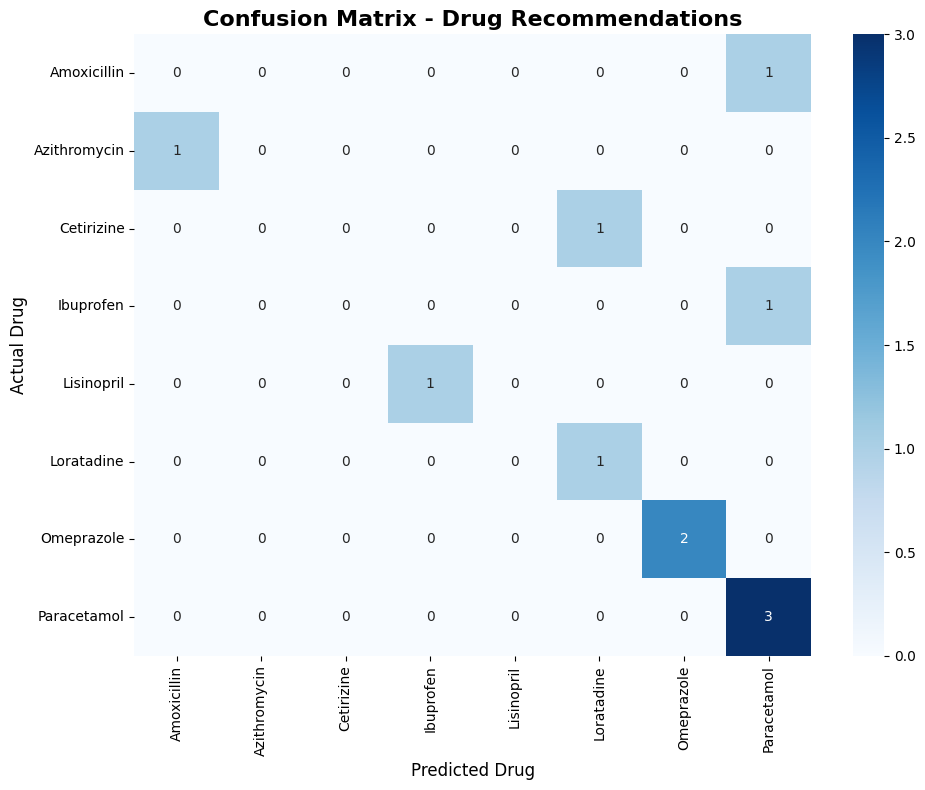

✓ Confusion matrix saved to models/confusion_matrix.png


In [8]:

# Cell 8: Confusion Matrix Visualization
"""
Visualize confusion matrix
"""

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.title('Confusion Matrix - Drug Recommendations', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Drug', fontsize=12)
plt.ylabel('Actual Drug', fontsize=12)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved to models/confusion_matrix.png")

Top 15 Most Important Features:
         feature  importance
47        gender    0.116161
46           age    0.113006
15         fever    0.095820
29          pain    0.056836
10         cough    0.049134
44        throat    0.047958
37    runny nose    0.034614
20     heartburn    0.034410
25       itching    0.033525
18      headache    0.032854
38      sneezing    0.030730
40   sore throat    0.024517
28          nose    0.022149
12      diabetes    0.021650
22  hypertension    0.020471


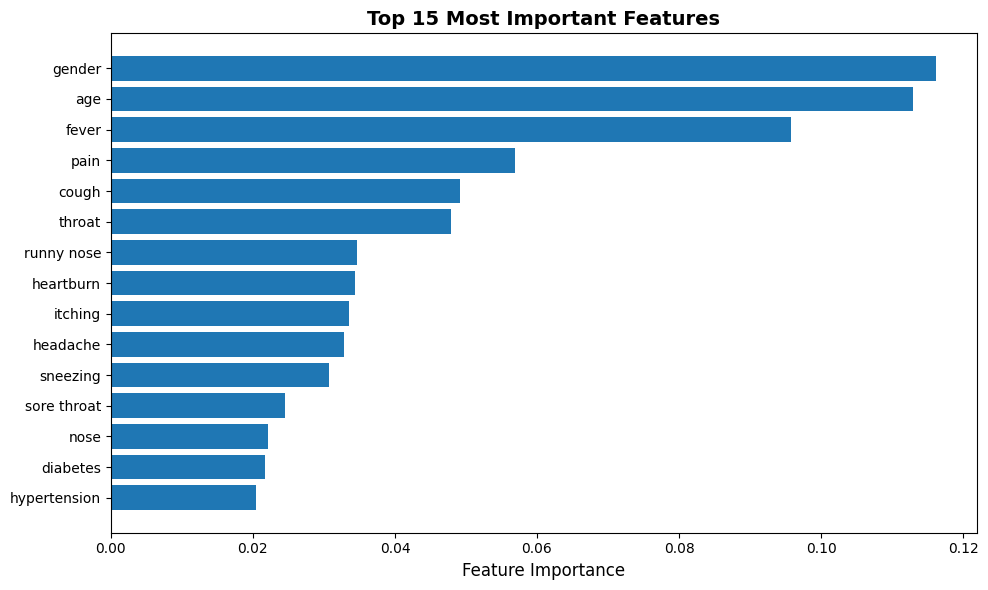

✓ Feature importance plot saved


In [9]:

# Cell 9: Feature Importance
"""
Analyze feature importance
"""

# Get feature importances
importances = model.feature_importances_

# Create feature names
feature_names = (
    vectorizer.get_feature_names_out().tolist() + 
    ['age', 'gender']
)

# Create dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance_df.head(15))

# Plot
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance plot saved")

In [10]:
# Cell 10: Test Model with Sample Input
"""
Test model with sample patient data
"""

# Test sample
test_patient = {
    'symptoms': 'fever, headache, body pain',
    'medical_history': 'none',
    'age': 35,
    'gender': 'Male'
}

# Preprocess
combined_text = (test_patient['symptoms'] + ' ' + test_patient['medical_history']).lower()
text_vec = vectorizer.transform([combined_text]).toarray()
age_vec = np.array([[test_patient['age']]])
gender_vec = np.array([[1 if test_patient['gender'] == 'Male' else 0]])

# Combine features
test_features = np.concatenate([text_vec, age_vec, gender_vec], axis=1)

# Predict
prediction = model.predict(test_features)[0]
probabilities = model.predict_proba(test_features)[0]

print(f"\n{'='*60}")
print(f"TEST PREDICTION")
print(f"{'='*60}")
print(f"Patient: {test_patient['age']}yo {test_patient['gender']}")
print(f"Symptoms: {test_patient['symptoms']}")
print(f"\nTop 3 Recommendations:")
print(f"{'='*60}")

# Get top 3 predictions
top_3_idx = np.argsort(probabilities)[-3:][::-1]
for idx in top_3_idx:
    drug = model.classes_[idx]
    confidence = probabilities[idx] * 100
    print(f"{drug:20s} - {confidence:.2f}% confidence")


TEST PREDICTION
Patient: 35yo Male
Symptoms: fever, headache, body pain

Top 3 Recommendations:
Paracetamol          - 49.89% confidence
Ibuprofen            - 11.88% confidence
Amoxicillin          - 11.31% confidence


In [11]:
# Cell 11: Save Model and Vectorizer
"""
Save trained model and vectorizer for Flask app
"""

import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save model
joblib.dump(model, '../models/drug_model.pkl')
print("✓ Model saved to models/drug_model.pkl")

# Save vectorizer
joblib.dump(vectorizer, '../models/vectorizer.pkl')
print("✓ Vectorizer saved to models/vectorizer.pkl")

# Save model metadata
metadata = {
    'model_type': 'RandomForestClassifier',
    'n_estimators': 100,
    'train_accuracy': train_accuracy,
    'test_accuracy': test_accuracy,
    'n_features': X.shape[1],
    'n_classes': len(model.classes_),
    'classes': model.classes_.tolist(),
    'training_samples': len(X_train),
    'test_samples': len(X_test)
}

import json
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✓ Model metadata saved")

print(f"\n{'='*60}")
print("MODEL TRAINING COMPLETE ✅")
print(f"{'='*60}")
print(f"Files saved in models/ directory:")
print(f"  - drug_model.pkl")
print(f"  - vectorizer.pkl")
print(f"  - model_metadata.json")
print(f"  - confusion_matrix.png")
print(f"  - feature_importance.png")
print(f"{'='*60}")
print(f"\nNext Step: Run Flask app to use trained model!")
print(f"  python app.py")
print(f"{'='*60}")

✓ Model saved to models/drug_model.pkl
✓ Vectorizer saved to models/vectorizer.pkl
✓ Model metadata saved

MODEL TRAINING COMPLETE ✅
Files saved in models/ directory:
  - drug_model.pkl
  - vectorizer.pkl
  - model_metadata.json
  - confusion_matrix.png
  - feature_importance.png

Next Step: Run Flask app to use trained model!
  python app.py
